# Kaggle Housing Price Prediction - Linear Model

Ridge regression solution for the [Kaggle Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/competitions/home-data-for-ml-course). Predicts residential home sale prices in Ames, Iowa. The competition metric is MAE on the raw price, but the model is trained on log(SalePrice) to reduce the influence of high-value outliers. This is equivalent to minimising RMSLE.

Ridge was initially selected because there is significant multicollinearity between many of the columns so Ridge should handle this better than something like LASSO that would totally drop some correlated features. Also there are only about 90 columns before one-hot encoding so we probably don't need to worry about column count. After the model was built with Ridge, I tried replacing it with Huber regression which is similar but more robust to outliers. Huber regression was found to perform better than Ridge.

Exploratory analysis and outlier identification are covered in `data-exploration.ipynb`. This notebook focuses on the modelling pipeline:

ADD PIPELINE

TODO:
- Try Huber regression. This should deal with outliers better and might help with reducing sensitivity to strange houses

In [270]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

import scipy.stats as stats
from scipy.optimize import minimize_scalar

from pandas.api.types import CategoricalDtype

from sklearn.linear_model import Ridge
from sklearn.linear_model import HuberRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import mutual_info_regression

import joblib
import plotly
import optuna
import optuna.visualization as vis

# set global theme and disable frames
sns.set_theme(style = 'white',
              rc={'legend.frameon': False},
              )
sns.set_style('ticks', {'xtick.major.size' : 8,
                        'ytick.major.size' : 8,
                        'xtick.bottom'     : True,
                        'ytick.left'       : True,
                        })

## Preprocessing

In [ ]:
def clean(df):
    '''
    Applies preliminary data cleaning to the provided
    dataframe based on the data exploration notebook
    '''
    # set missing GarageYrBlt values to YearBuilt
    df.loc[df['GarageYrBlt'] < df['YearBuilt'], 'GarageYrBlt'] = df['YearBuilt']

    # drop columns that are missing a significant amount of data
    df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType'])

    # note: FireplaceQu has >40% missing values but can be imputed with
    # ordinal encoding so might be worth keeping

    # set all the continuous variables to float dtype
    continuous_cols = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                       'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
                       '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']

    df[continuous_cols] = df[continuous_cols].astype(float) # eventually TotBath will be a float but not continuous!

    return df


def remove_outliers(df):
    '''
    Two Edwards neighbourhood partial sales identified in data-exploration.ipynb that
    seem like outliers. Large area, good quality, but low price. Remove these
    from the training data
    '''
    mask = ((df['Neighborhood'] == 'Edwards') &
            (df['SaleCondition'] == 'Partial') &
            (df['GrLivArea'] > 4000))
    
    return df[~mask]


def impute(df, impute_stats=None):
    '''
    Impute the columns in the provided dataframe
    based on the results of the cells above

    impute_stats is a dict that specifies values to
    use for imputing that need to be collected from
    training data 
    '''
    # first handle special cases

    # estimate missing LotFrontage by the root of LotArea
    df['RootArea']    = np.sqrt(df['LotArea'])
    df['LotFrontage'] = df['LotFrontage'].fillna(df['RootArea'])
    df = df.drop(columns=['RootArea'])

    # set missing GarageYrBlt with YearBuilt
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    # impute the missing Electrical data with the mode
    if impute_stats is None:
        impute_stats = {'Electrical' : df['Electrical'].mode()[0]}
    
    df['Electrical'] = df['Electrical'].fillna(impute_stats['Electrical'])


    # general handling for the rest of the columns
    for col in df.select_dtypes('object', 'category'):
        df[col] = df[col].fillna('NA')
    
    for col in df.select_dtypes('number'):
        df[col] = df[col].fillna(0)
    
    return df, impute_stats


def encode(df):
    '''
    Encode the categorical columns of the provided dataframe
    based on the encoding outlined below
    '''
    # categorical columns
    categorical_cols = set(df.select_dtypes('object', 'category').columns)

    nominative_cols = ['MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig',
                       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
                       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation',
                       'Heating', 'Electrical', 'Functional', 'SaleType', 'SaleCondition',
                       'GarageType']

    ordinal_cols = list(categorical_cols - set(nominative_cols))

    ordinal_encoding = {'LotShape'      : ['Reg', 'IR1', 'IR2', 'IR3'],
                        'LandSlope'     : ['Gtl', 'Mod', 'Sev'],
                        'ExterQual'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'ExterCond'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtQual'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtCond'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtExposure'  : ['No', 'Mn', 'Av', 'Gd'],
                        'BsmtFinType1'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'BsmtFinType2'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'HeatingQC'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'CentralAir'    : ['N', 'Y'],
                        'KitchenQual'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'FireplaceQu'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageQual'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageCond'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageFinish'  : ['Unf', 'RFn', 'Fin'],
                        'PavedDrive'    : ['N', 'P', 'Y'],
                        }

    ordinal_encoding = {key: ['NA'] + values for key, values in ordinal_encoding.items()}

    for col in nominative_cols:
        df[col] = df[col].astype('category')
    
    for col in ordinal_cols:
        df[col] = df[col].astype(CategoricalDtype(ordinal_encoding[col], ordered=True))
    
    return df

## Load Data

Apply the full preprocessing pipeline. The `impute_stats` dict is fit on the training set and passed through to the test set so the test data never influences any computed statistics.

In [5]:
def load_data():
    # Load the Kaggle dataset
    path_train = './input/train.csv.gz'
    path_test  = './input/test.csv.gz'

    train_full = pd.read_csv(path_train, compression='gzip', index_col='Id')
    test_full  = pd.read_csv(path_test, compression='gzip', index_col='Id')

    train = train_full.copy()
    train = clean(train)
    train = remove_outliers(train)
    train, impute_stats = impute(train)
    train = encode(train)

    test = test_full.copy()
    test = clean(test)
    test, _ = impute(test, impute_stats)
    test = encode(test)

    return train, test

train, test = load_data()

print(f'Shape of train dataset: {train.shape}')
print(f'Shape of test dataset:  {test.shape}')

# remove training rows with missing target (SalePrice)
print(f'{train["SalePrice"].isna().sum()} trainig rows have a missing SalePrice')
train = train.dropna(subset=['SalePrice']) # no missing SalePrice so not needed

# remove any duplicate training rows
print(f'{train.duplicated().sum()} trainig rows are duplicates')
train = train.drop_duplicates(keep='first') # no duplicates so not needed

Shape of train dataset: (1458, 75)
Shape of test dataset:  (1459, 74)
0 trainig rows have a missing SalePrice
0 trainig rows are duplicates


## Baseline Model

Establish a baseline score using Ridge with a default alpha parameter on the raw features before any feature engineering. The scoring function uses 5-fold cross-validation and reports RMSE on log(`SalePrice`), consistent with the competition's RMSLE metric.

In [277]:
def cat_to_codes(X):
    '''
    Convert ordinal CategoricalDtype columns to integer codes so that
    Ridge can understand the ranking
    '''
    X = X.copy()
    for col in X.select_dtypes('category'):
        if X[col].cat.ordered:
            X[col] = X[col].cat.codes

    return X


def prepare_features_linear(X):
    '''
    Convert categoricals for Ridge. Ordinal columns are converted to
    int codes, nominal columns are converted to one-hot encoding
    '''
    X = cat_to_codes(X)
    X = pd.get_dummies(X, drop_first=True)
    return X


def score_model(X, y):
    '''
    Return a score using cross validation to estimate
    model performance. This competition uses RMSE between
    log prices so use that as a metric
    '''
    ridge_pipeline = Pipeline([('scaler', StandardScaler()),
                               ('model',  Ridge(random_state=123)),
                               ])

    log_y    = np.log(y)
    X_linear = prepare_features_linear(X)

    scores = cross_val_score(ridge_pipeline, X_linear, log_y, cv=5, scoring='neg_mean_squared_error')
    score  = -1 * scores.mean()
    score  = np.sqrt(score)

    return score


def score_model_huber(X, y):
    '''
    Return a score using cross validation to estimate
    model performance. This competition uses RMSE between
    log prices so use that as a metric

    This uses Huber regression as an alternative to Ridge
    '''    
    huber_pipeline = Pipeline([('scaler', StandardScaler()),
                               ('model',  HuberRegressor(max_iter=1000)),
                               ])

    log_y    = np.log(y)
    X_linear = prepare_features_linear(X)

    scores = cross_val_score(huber_pipeline, X_linear, log_y, cv=5, scoring='neg_mean_squared_error')
    score  = -1 * scores.mean()
    score  = np.sqrt(score)

    return score

In [12]:
X = train.copy()
y = X.pop('SalePrice')

baseline_score = score_model(X, y)
print(f'Baseline model score: {baseline_score:.5f} RMSE')

Baseline model score: 0.12270 RMSE


## Feature Engineering

Construct additional features from the raw columns. These fall into a few categories:

- **Ratios and Products**: ex. relative size of the house vs the lot
- **Totals**: ex. combined square footage
- **Ages**: ex. years since the house was built
- **Presence flags**: ex. binary flag for a house having a garage
- **Neighbourhood statistics**: ex. difference between living area to mean neighbourhood living area

In [205]:
def combinations(df):
    '''
    Creates a dataframe of new columns X which
    are meaningful mathematical transformations
    of the columns in df 
    '''
    X = pd.DataFrame(index=df.index)

    # ratios
    X['LivLotRatio']   = df['GrLivArea'] / df['LotArea'] # size of house vs size of property
    X['PorchLotRatio'] = df[['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
                             '3SsnPorch', 'ScreenPorch']].sum(axis=1) / df['LotArea'] # how much of the lot is covered by decks
    X['Spaciousness']  = (df['1stFlrSF'] + df['2ndFlrSF']) / df['TotRmsAbvGrd'] # are the rooms spacious

    # products
    X['QualArea']     = df['OverallQual'] * df['GrLivArea'] # more area of higher quality should be more expensive

    # totals
    X['TotBath']      = df[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * df[['BsmtHalfBath', 'HalfBath']].sum(axis=1) # total bathroom count
    X['TotalPorchSF'] = df[['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].sum(axis=1) # total porch area
    X['TotalSF']      = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] # total interior SF

    # ages
    X['Age']          = df['YrSold'] - df['YearBuilt'] # how old is the house explicitly (newer houses should be more expensive?)
    X['AgeOfRemod']   = df['YrSold'] - df['YearRemodAdd'] # how old is the remodel (more recent also more expensive?)

    return X


def set_flags(df):
    '''
    Sets flags for features that have 0s (does X
    exist in this house)
    '''
    df['Has2ndFlr']    = (~df['2ndFlrSF'].eq(0)).astype(int) # is there a second floor?
    df['HasBasement']  = (~df['TotalBsmtSF'].eq(0)).astype(int) # is there a basement?
    df['HasPorch']     = (~df['TotalPorchSF'].eq(0)).astype(int) # is there any kind of porch?
    df['HasGarage']    = (~df['GarageArea'].eq(0)).astype(int) # is there a garage?
    df['HasMasVnr']    = (~df['MasVnrArea'].eq(0)).astype(int) # is there masonry veneer?

    return


def drop_linear_combos(df):
    '''
    Remove columns that were combined into new features
    in linear combinations

    Note: choose to keep TotalBsmtSF so that we still
    know the total size of the basement
    '''
    return df.drop(columns=['BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath',
                            '1stFlrSF', '2ndFlrSF', 'WoodDeckSF', 'OpenPorchSF',
                            'EnclosedPorch', '3SsnPorch', 'ScreenPorch'])


def group_transforms(df, group_stats=None):
    '''
    Creates a dataframe of new columns which are group-level
    statistics per Neighborhood, computed from training data.
    The mean / median group stats used in the BDT model are
    not so relevant here because they can be infered by the
    linear model when the column gets one-hot encoded.

    group_stats: dict of pre-computed Series (fit on train).
                 If None, stats are computed from df — only pass
                 None when df is the training set.
    '''
    if group_stats is None:
        group_stats = {'MedNhbdLivArea'  : df.groupby('Neighborhood', observed=False)['GrLivArea'].median()}

    X = pd.DataFrame(index=df.index)
    X['MedNhbdLivArea']  = df['Neighborhood'].map(group_stats['MedNhbdLivArea']).astype(float)
    X['MedNhbdLivDiff']  = df['GrLivArea'] - X['MedNhbdLivArea']

    X = X.drop(columns=['MedNhbdLivArea']) # don't need to save this

    return X, group_stats

In [206]:
X = train.copy()
y = X.pop('SalePrice')

X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

X.set_flags()
X = drop_linear_combos(X)

print(f'Model score: {score_model(X, y):.5f} RMSE')

Model score: 0.12016 RMSE


## Log Scale Right-Skewed Continuous Features
Do this to remove heteroskedasticity. Many columns have a "conic" relationship with `SalePrice` meaning that the variance in the data increases with the dependent variable. Log scaling both `SalePrice` and the independent variable can help mitigate this problem.

More in depth analysis of this in the data exploration notebook

In [253]:
def qq_correlation(series):
    '''
    Pearson correlation coefficient between sample quantiles and
    theoretical normal quantiles. Normally distributed data will
    have a correlation coefficient close to 1
    '''
    (_, _), (_, _, corr_coef) = stats.probplot(series)

    return corr_coef


def apply_normality(df, cols_to_normalize=None, verbose=False):
    '''
    Applies log scaling to features if they
    are right-skewed and doing so improves
    the QQ normality

    MedNhbdLivDiff excluded because it has
    negative values!

    Ratios and products are also excluded because
    if log scaled, they become linear combinations
    of the log scaled original columns!
    log(AB) = log(A) + log(B)
    '''
    continuous_cols = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1',
                       'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'TotalSF',
                       'TotalPorchSF', 'BsmtFinSF2', 'LowQualFinSF', 'PoolArea',
                       'MiscVal']
    norm_df = df.copy()

    # check the skew (right skew should be log scaled)
    norm_stats = pd.DataFrame(norm_df[continuous_cols].skew(), columns=['skew'])

    # calculate the qq pearson correlation to quantify column normality
    # (ignore 0 values)
    qq_corrs = pd.Series({col: qq_correlation(norm_df[norm_df[col]>0][col])
                        for col in norm_df[continuous_cols]})

    qq_corrs   = pd.DataFrame(qq_corrs, columns=['normal_corr'])
    norm_stats = norm_stats.join(qq_corrs)

    # now rerun with log scaling
    log_qq_corrs = pd.Series({col: qq_correlation(np.log(norm_df[norm_df[col]>0][col]))
                            for col in norm_df[continuous_cols]})

    log_qq_corrs = pd.DataFrame(log_qq_corrs, columns=['log_normal_corr'])
    norm_stats   = norm_stats.join(log_qq_corrs)

    # determine which columns to normalize
    if cols_to_normalize is None:
        cols_to_normalize = norm_stats[(norm_stats['skew'] > 0) &
                                       (norm_stats['log_normal_corr'] > norm_stats['normal_corr'])].index.to_list()
    
    if verbose:
        print('Log scaling the following columns:')
        print(cols_to_normalize)
    
    for col in cols_to_normalize:
        # just use log1p for all because it handles 0s and all values are >> 1
        # don't need to worry about adding flag columns because those already exist
        norm_df[col] = np.log1p(norm_df[col])
    
    return norm_df, cols_to_normalize

In [254]:
X = train.copy()
y = X.pop('SalePrice')

X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

X.set_flags()
X = drop_linear_combos(X)

X, _ = apply_normality(X, verbose=True)

print(f'Model score: {score_model(X, y):.5f} RMSE')

Log scaling the following columns:
['LotFrontage', 'LotArea', 'MasVnrArea', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'TotalSF', 'TotalPorchSF', 'BsmtFinSF2', 'PoolArea', 'MiscVal']
Model score: 0.11781 RMSE


## Feature Selection via Mutual Information and Pearson Correlation

Mutual information can help identify which columns are the most important for predicitng `SalePrice`, even when the relationship is non-linear. However, since we're using Ridge, which is a linear model, columns with high mutual information but with a non-linear relationship won't be as effective in the model. Hence, we also consider the Pearson correlation with `SalePrice` to see which columns also have a linear relationship.

Note: These statistics only show the marginal importance of each feature. Because Ridge is a joint estimator, it benefits from features that reduce conditional variance in other predictors, even if those features have near-zero marginal signal.

Ended up deciding to drop columns with minimal mutual information (less than 0.05). Observed that even columns with low MI seem to benefit the model.

In [247]:
def get_mi_scores(X, y):
    '''
    Calculate mutual information scores between columns
    in X and target in y
    '''
    X = X.copy()
    for col in X.select_dtypes(['category']):
        X[col] = X[col].cat.codes

    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=123)
    mi_scores = pd.Series(mi_scores, name='MI_Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)

    return mi_scores


def get_pearson_corr(X, y, exclude_zeros=False):
    '''
    Return the Pearson correlation of all the
    columns in X with y. Optional flag to ignore
    0 values.
    '''
    X = X.copy()

    if exclude_zeros:
        X = X.replace(0, np.nan)
    
    correlation_scores = X.corrwith(y, method='pearson')
    correlation_scores = pd.Series(correlation_scores, name='Pearson_Corr', index=X.columns)
    correlation_scores = correlation_scores.sort_values(ascending=False)

    return correlation_scores

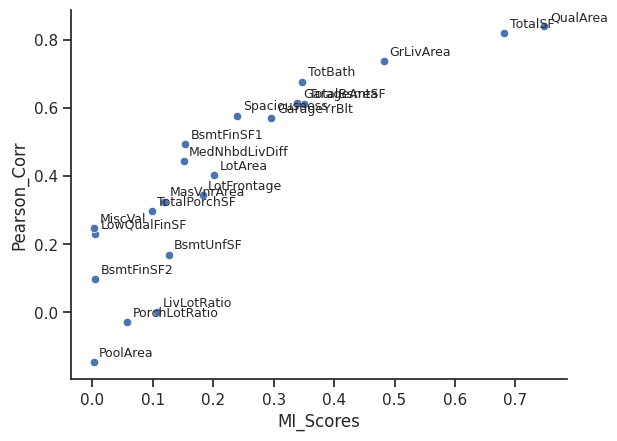

In [248]:
base_cols  = X.select_dtypes('float')
target_col = np.log(y)

column_scores = pd.DataFrame(get_mi_scores(base_cols, target_col))
column_scores = column_scores.join(pd.DataFrame(get_pearson_corr(base_cols, target_col, exclude_zeros=True)))

# display results in a scatter plot
fig, ax = plt.subplots()

sns.scatterplot(column_scores, x='MI_Scores', y='Pearson_Corr', ax=ax)
sns.despine()

for row in column_scores.iterrows():
    ax.annotate(str(row[0]), xy=(row[1]['MI_Scores'], row[1]['Pearson_Corr']),
                xytext=(4, 4), textcoords='offset points', fontsize=9)

plt.show()

In [ ]:
def drop_uninformative(df, mi_scores, drop_threshold, verbose=False):
    '''
    Remove columns with 0 mutual information
    '''
    if verbose:
        print('Uninformative columns that will be dropped:')
        print(mi_scores.index[mi_scores.le(drop_threshold)].to_list())
    return df.loc[:, mi_scores > drop_threshold]


def error_given_drop_threshold(thresdhold):
    X = train.copy()
    y = X.pop('SalePrice')

    X = X.join(combinations(X))

    group_features, group_stats = group_transforms(X)
    X = X.join(group_features)

    X.set_flags()
    X = drop_linear_combos(X)

    X, _ = apply_normality(X)

    mi_scores = get_mi_scores(X, np.log(y))
    X = drop_uninformative(X, mi_scores, drop_threshold=thresdhold)

    return score_model(X, y)

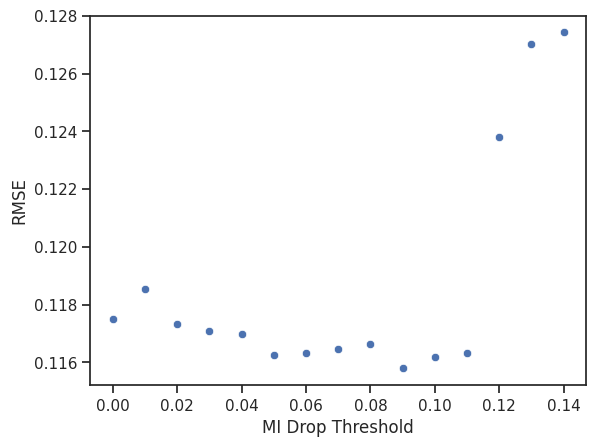

In [ ]:
# quick scan to find the best feature drop threshold
test_thresholds = np.arange(0, 0.15, 0.01)

errors = []
for threshold in test_thresholds:
    errors.append(error_given_drop_threshold(threshold))

# plot results
fig, ax = plt.subplots()
sns.scatterplot(x=test_thresholds, y=errors, ax=ax)

ax.set_xlabel('MI Drop Threshold')
ax.set_ylabel('RMSE')

plt.show()

# looks like the optimal choice is about 0.09

In [278]:
X = train.copy()
y = X.pop('SalePrice')

X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

X.set_flags()
X = drop_linear_combos(X)

X, _ = apply_normality(X)

mi_scores = get_mi_scores(X, np.log(y))
X = drop_uninformative(X, mi_scores, drop_threshold=0.09, verbose=True)

print('Model performance before optimizing hyperparameters:')
print(f'Final Ridge regression model cross validation score: {score_model(X, y):.5f} RMSE')
print(f'Final Huber regression model cross validation score: {score_model_huber(X, y):.5f} RMSE')

Uninformative columns that will be dropped:
['HouseStyle', 'SaleType', 'BsmtExposure', 'SaleCondition', 'GarageCond', 'BedroomAbvGr', 'GarageQual', 'CentralAir', 'PorchLotRatio', 'BsmtCond', 'PavedDrive', 'Electrical', 'BldgType', 'BsmtFinType2', 'LandContour', 'ExterCond', 'Condition1', 'KitchenAbvGr', 'Heating', 'RoofStyle', 'LotConfig', 'Functional', 'RoofMatl', 'BsmtFinSF2', 'LowQualFinSF', 'LandSlope', 'MiscVal', 'Condition2', 'PoolArea', 'Utilities', 'Street', 'MoSold', 'YrSold']
Model performance before optimizing hyperparameters:
Final Ridge regression model cross validation score: 0.11579 RMSE
Final Huber regression model cross validation score: 0.11487 RMSE


## Final Feature Set

Assemble the complete feature set used for training and prediction. The `group_stats` dict (neighbourhood medians/stds) is fit on the training set and applied to the test set to prevent leakage of the test dataset. Huber regression outperforms Ridge before hyperparameter tuning so Huber is the linear model of choice.

In [257]:
def create_features(df, df_test=None):
    '''
    Combined function to set up all the model features based on
    Feature Engineering for Housing Prices Kaggle notebook
    '''
    X = df.copy()
    y = X.pop('SalePrice')

    X = X.join(combinations(X))

    group_features, group_stats = group_transforms(X)
    X = X.join(group_features)

    X.set_flags()
    X = drop_linear_combos(X)

    X, cols_to_normalize = apply_normality(X)

    mi_scores = get_mi_scores(X, np.log(y))
    X = drop_uninformative(X, mi_scores, drop_threshold=0.09)

    # Choose not to combine splits to avoid leakage of test data
    # into train data. This would probably give better performance
    # for the Kaggle competition but probably not good when
    # making a general model that is supposed to predict unseen data

    # set up test data
    if df_test is not None:
        X_test = df_test.copy()

        X_test = X_test.join(combinations(X_test))

        group_features, _ = group_transforms(X_test)
        X_test = X_test.join(group_features)

        X_test.set_flags()
        X_test = drop_linear_combos(X_test)

        X_test, _ = apply_normality(X_test, cols_to_normalize)

        X_test = drop_uninformative(X_test, mi_scores, drop_threshold=0.09)

        return X, X_test
    else:
        return X

## Hyperparameter Tuning with Optuna

Optuna uses Bayesian optimisation to search the hyperparameter space. Each trial informs the next, making it more efficient than random search for the same number of trials. The objective function is 5-fold cross-validated log-RMSE on the training set.

In [258]:
df_train, df_test = load_data()
X_train = create_features(df_train)
y_train = df_train['SalePrice']

log_y_train = np.log(y_train)

In [282]:
def objective_Huber(trial):
    params = {'epsilon' : trial.suggest_float('epsilon', 1.01, 2.0),
              'alpha'   : trial.suggest_float('alpha', 1e-4, 50.0, log=True),
              'max_iter': 2000,
              }

    huber_pipeline = Pipeline([('scaler', StandardScaler()),
                               ('model',  HuberRegressor(**params)),
                               ])
    X_linear = prepare_features_linear(X_train)

    scores = cross_val_score(huber_pipeline, X_linear, log_y_train, cv=5, scoring='neg_mean_squared_error')

    return np.sqrt(-scores.mean())

In [284]:
# load cached study
huber_study = joblib.load('./optuna-cache/huber-optuna-study.joblib')

# # rerun study
# huber_study = optuna.create_study(direction='minimize')
# huber_study.optimize(objective_Huber, n_trials=50)

# # cache hyperparameter optimization so it doesn't have to rerun
# joblib.dump(huber_study, './optuna-cache/huber-optuna-study.joblib')

print(f'Best RMSE:   {huber_study.best_value:.5f}')
print(f'Best params: {huber_study.best_params}')

Best RMSE:   0.11449
Best params: {'epsilon': 1.94973773262454, 'alpha': 8.787484338302674}


### Visualize Hyperparameter Tuning

In [285]:
study = huber_study # lgbm_study

# how the objective value improved over trials
vis.plot_optimization_history(study).show()

# which hyperparameters mattered most
# vis.plot_param_importances(study).show()

# 2D slice of the objective surface
# vis.plot_contour(study, params=['learning_rate', 'reg_alpha']).show()

# distribution of sampled values vs objective score
# vis.plot_slice(study).show()

## Generate Predictions

Fig Ridge model on the full training set using the best alpha hyperparameter found by Optuna, then predict on the test

In [287]:
X_train, X_test = create_features(df_train, df_test)
y_train         = df_train['SalePrice']

huber_pipeline = Pipeline([('scaler', StandardScaler()),
                            ('model', HuberRegressor(**huber_study.best_params, max_iter=2000)),
                            ])

X_linear_train = prepare_features_linear(X_train)
log_y          = np.log(y_train)

# log transform because competition is looking at error in log price
huber_pipeline.fit(X_linear_train, log_y)

# Columns in train but absent from test are filled with 0,
# meaning that this category was not present. Columns in test
# but absent from train are dropped, since the fitted model
# has no coefficient for them
X_linear_test = prepare_features_linear(X_test).reindex(columns=X_linear_train.columns, fill_value=0)

predictions_huber = np.exp(huber_pipeline.predict(X_linear_test))

output = pd.DataFrame({'Id'        : X_test.index,
                       'SalePrice' : predictions_huber,
                       })
output.to_csv('./output/huber-submission.csv', index=False)

In [ ]:
# add ablation to bdt notebook????